In [1]:
import pandas as pd

TRANSACTION_CSV = "train_transaction.csv"
IDENTITY_CSV = "train_identity.csv"

trans_cols = pd.read_csv(TRANSACTION_CSV, nrows=0).columns.tolist()
id_cols = pd.read_csv(IDENTITY_CSV, nrows=0).columns.tolist()

print(f"train_transaction.csv has {len(trans_cols)} columns")
print(trans_cols)
print()
print(f"train_identity.csv has {len(id_cols)} columns")
print(id_cols)

train_transaction.csv has 394 columns
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76',

In [2]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
import hdbscan
import matplotlib.pyplot as plt

# --- shared schema: keep these names in sync with the rest of the team ---
TRANSACTION_CSV = "train_transaction.csv"
IDENTITY_CSV = "train_identity.csv"

ID_COL = "TransactionID"
TARGET_COL = "isFraud"
UID_COL = "entity_uid"

# columns that can be SHARED between transactions -> become graph edges
ENTITY_COLUMNS = ["card1","card2","card3","card4","card5","card6",
                   "addr1","addr2","P_emaildomain","R_emaildomain",
                   "DeviceType","DeviceInfo","id_30","id_31"]

# columns used only to build the pseudo-UID (entity linking)
UID_SOURCE_COLUMNS = ["card1", "addr1", "D1"]

# behavioral/numeric columns -> features for the anomaly detection model
BASE_BEHAVIOR_COLUMNS = ["TransactionAmt","TransactionDT"] + \
    [f"C{i}" for i in range(1,15)] + [f"D{i}" for i in range(2,16)]

SAMPLE_SIZE = 590_540
N_V_COLUMNS_TO_KEEP = 25
RANDOM_SEED = 42

## Load and merge

In [3]:
df_trans = pd.read_csv(TRANSACTION_CSV)
df_id = pd.read_csv(IDENTITY_CSV)
df = df_trans.merge(df_id, on=ID_COL, how="left")
print(df.shape)

(590540, 434)


## pseudo-UID (entity linking)

In [4]:
# NaN if card1/addr1/D1 is missing: we don't want to link two transactions
# just because they share a missing value
complete_mask = df[UID_SOURCE_COLUMNS].notna().all(axis=1)
uid = (df["card1"].astype("Int64").astype(str) + "_" +
       df["addr1"].astype("Int64").astype(str) + "_" +
       df["D1"].round(0).astype("Int64").astype(str))
df[UID_COL] = np.where(complete_mask, uid, np.nan)
print(f"UID coverage: {df[UID_COL].notna().mean():.1%}")

UID coverage: 88.7%


C:\Users\deend\AppData\Local\Temp\ipykernel_30652\1478649032.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[UID_COL] = np.where(complete_mask, uid, np.nan)


## final columns 
In the dataset we don't know what those values are because of anonymization 

In [5]:
# no more supervised selection here: keep every V-column, reduce them
# with unsupervised PCA later (after sampling, to stay fast)
v_cols = [c for c in df.columns if c.startswith("V")]

final_cols = [ID_COL, TARGET_COL, UID_COL] + ENTITY_COLUMNS + BASE_BEHAVIOR_COLUMNS + v_cols
final_cols = [c for c in final_cols if c in df.columns]
df = df[final_cols]

frac = min(SAMPLE_SIZE, len(df)) / len(df)
parts = [g.sample(frac=frac, random_state=RANDOM_SEED) for _, g in df.groupby(TARGET_COL)]
df = pd.concat(parts, ignore_index=True)
print(df.shape, df[TARGET_COL].mean())

(590540, 386) 0.03499000914417313


## PCA unsupervised after sampling

In [6]:
N_V_PCA_COMPONENTS = 15

X_v = df[v_cols].fillna(df[v_cols].median(numeric_only=True))
X_v_scaled = StandardScaler().fit_transform(X_v)

pca_v = PCA(n_components=N_V_PCA_COMPONENTS, random_state=RANDOM_SEED)
V_components = pca_v.fit_transform(X_v_scaled)
print(f"{N_V_PCA_COMPONENTS} components explain {pca_v.explained_variance_ratio_.sum():.1%} of V-columns variance")

# add them back to df as normal columns, so the rest of the pipeline
# doesn't need to change (Vpca_0, Vpca_1, ...)
for i in range(N_V_PCA_COMPONENTS):
    df[f"Vpca_{i}"] = V_components[:, i]

15 components explain 65.2% of V-columns variance


C:\Users\deend\AppData\Local\Temp\ipykernel_30652\1771922579.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"Vpca_{i}"] = V_components[:, i]


## prepare behavioral features (non top V)

In [7]:
behavior_cols = [c for c in BASE_BEHAVIOR_COLUMNS if c in df.columns] + \
                [f"Vpca_{i}" for i in range(N_V_PCA_COMPONENTS)]
X = df[behavior_cols].fillna(df[behavior_cols].median(numeric_only=True)).fillna(0)
X_scaled = StandardScaler().fit_transform(X)

# Isolation forest + anomaly score

In [8]:
iso = IsolationForest(n_estimators=200, contamination="auto",
                       random_state=RANDOM_SEED, n_jobs=-1)
iso.fit(X_scaled)
raw = -iso.score_samples(X_scaled)  # higher raw = more anomalous
df["anomaly_score"] = (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)

C:\Users\deend\AppData\Local\Temp\ipykernel_30652\3382801278.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["anomaly_score"] = (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)


# HDBSCAN -> cluster_id

In [9]:
X_pca = PCA(n_components=10, random_state=RANDOM_SEED).fit_transform(X_scaled)
clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10)
df["cluster_id"] = clusterer.fit_predict(X_pca)
print(df["cluster_id"].value_counts().head(10))

cluster_id
-1      447392
 39      15097
 157      5400
 402      4380
 450      4326
 269      4175
 238      4118
 289      3168
 164      3098
 63       2949
Name: count, dtype: int64


C:\Users\deend\AppData\Local\Temp\ipykernel_30652\1492319418.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["cluster_id"] = clusterer.fit_predict(X_pca)


## validation against isFraud (sanity check only, not used for training)

In [10]:
auc = roc_auc_score(df[TARGET_COL], df["anomaly_score"])
print(f"AUC anomaly_score vs isFraud: {auc:.3f}")
print(df.groupby("cluster_id")[TARGET_COL].agg(["mean","count"]).sort_values("mean", ascending=False).head(10))

AUC anomaly_score vs isFraud: 0.674
                mean  count
cluster_id                 
148         0.232558     86
41          0.187500     96
83          0.173913     92
31          0.134615     52
0           0.134328    134
4           0.130435    322
134         0.130435     69
225         0.125000     64
339         0.114130    184
1           0.113636    308


In [11]:
import networkx as nx
import community as community_louvain  # pip install python-louvain
from collections import Counter

ENTITY_COLUMNS = ["card1","card2","card3","card4","card5","card6",
                   "addr1","addr2","P_emaildomain","R_emaildomain",
                   "DeviceType","DeviceInfo","id_30","id_31"]

G = nx.Graph()

# transaction nodes: usa anomaly_score/cluster_id già calcolati
for tx_id, is_fraud, score in zip(df[ID_COL], df[TARGET_COL], df["anomaly_score"]):
    G.add_node(tx_id, node_type="Transaction", is_fraud=int(is_fraud), anomaly_score=float(score))

# entity nodes + archi, colonna per colonna (niente iterrows sull'intero df)
entity_freq = Counter()
edges_by_col = {}
for col in ENTITY_COLUMNS:
    sub = df[[ID_COL, col]].dropna(subset=[col])   # skip NaN -> no falso nodo condiviso
    sub = sub.assign(entity_node=col + "_" + sub[col].astype(str))
    edges_by_col[col] = sub
    entity_freq.update(sub["entity_node"].value_counts().to_dict())

hub_threshold = len(df) * 0.01  # entità in più dell'1% delle transazioni = hub, peso penalizzato

for col, sub in edges_by_col.items():
    for tx_id, entity_node in zip(sub[ID_COL], sub["entity_node"]):
        freq = entity_freq[entity_node]
        weight = 0.01 / freq if freq > hub_threshold else 1.0 / (1.0 + np.log(freq))
        if not G.has_node(entity_node):
            G.add_node(entity_node, node_type=col, frequency=freq)
        G.add_edge(tx_id, entity_node, relationship=col, weight=weight)

print(f"Graph: {G.number_of_nodes()} nodi, {G.number_of_edges()} archi")

Graph: 607352 nodi, 5685701 archi


In [12]:
# community detection + statistiche (sostituisce il "groupby manuale su card1/DeviceInfo" di prima)
partition = community_louvain.best_partition(G, weight="weight")
pagerank = nx.pagerank(G, alpha=0.85, weight="weight")

df["community_id"] = df[ID_COL].map(partition)
df["pagerank"] = df[ID_COL].map(pagerank)

community_summary = df.groupby("community_id").agg(
    n_transactions=(TARGET_COL, "count"),
    n_fraud=(TARGET_COL, "sum"),
    fraud_rate=(TARGET_COL, "mean"),
).query("n_transactions > 1").sort_values("fraud_rate", ascending=False)

df["community_fraud_rate"] = df["community_id"].map(community_summary["fraud_rate"])

print(f"{community_summary.shape[0]} community con più di 1 transazione")
community_summary.head(10)

C:\Users\deend\AppData\Local\Temp\ipykernel_30652\2309816014.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["community_id"] = df[ID_COL].map(partition)


1572 community con più di 1 transazione


C:\Users\deend\AppData\Local\Temp\ipykernel_30652\2309816014.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["pagerank"] = df[ID_COL].map(pagerank)
C:\Users\deend\AppData\Local\Temp\ipykernel_30652\2309816014.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["community_fraud_rate"] = df["community_id"].map(community_summary["fraud_rate"])


,n_transactions,n_fraud,fraud_rate
community_id,,,
2294,6,6,1.000000
2305,2,2,1.000000
2295,3,3,1.000000
2296,3,3,1.000000
2293,4,4,1.000000
2297,8,8,1.000000
742,47,46,0.978723
1215,7,6,0.857143
1469,9,7,0.777778


In [13]:
cluster4 = df[df["cluster_id"] == 4]
for col in ["card1", "addr1", "DeviceType", "DeviceInfo", "P_emaildomain"]:
    print(col)
    print(cluster4[col].value_counts(dropna=False).head(5))
    print()

card1
card1
15063    20
6019     15
7585     10
16659    10
2616      9
Name: count, dtype: int64

addr1
addr1
299.0    52
204.0    30
330.0    22
325.0    19
191.0    15
Name: count, dtype: int64

DeviceType
DeviceType
desktop    267
mobile      45
NaN         10
Name: count, dtype: int64

DeviceInfo
DeviceInfo
rv:11.0        195
Windows         53
iOS Device      40
Trident/7.0     18
MacOS           10
Name: count, dtype: int64

P_emaildomain
P_emaildomain
gmail.com        113
anonymous.com     81
outlook.com       29
yahoo.com         23
aol.com           21
Name: count, dtype: int64



In [14]:
for col in ["entity_uid", "card1", "DeviceInfo", "P_emaildomain"]:
    agg = df.groupby(col)[TARGET_COL].agg(fraud_count="sum", n="count", fraud_rate="mean")
    agg = agg[agg["n"] >= 3].sort_values("fraud_count", ascending=False)  # entità viste almeno 3 volte
    print(col)
    print(agg.head(5))
    print()

entity_uid
             fraud_count     n  fraud_rate
entity_uid                                
9500_204_0            53  1919    0.027619
1764_315_0            44   233    0.188841
12695_325_0           41  1737    0.023604
17188_299_0           37  2430    0.015226
6019_325_0            32   496    0.064516

card1
       fraud_count      n  fraud_rate
card1                                
9633           742   4158    0.178451
9500           528  14162    0.037283
15885          444  10361    0.042853
9026           397   2076    0.191233
15063          319   2522    0.126487

DeviceInfo
                        fraud_count      n  fraud_rate
DeviceInfo                                            
Windows                        3121  47722    0.065400
iOS Device                     1240  19782    0.062683
MacOS                           278  12573    0.022111
hi6210sft Build/MRA58K          180    190    0.947368
SM-A300H Build/LRX22G           169    203    0.832512

P_emaildomain
   

## Quick plot

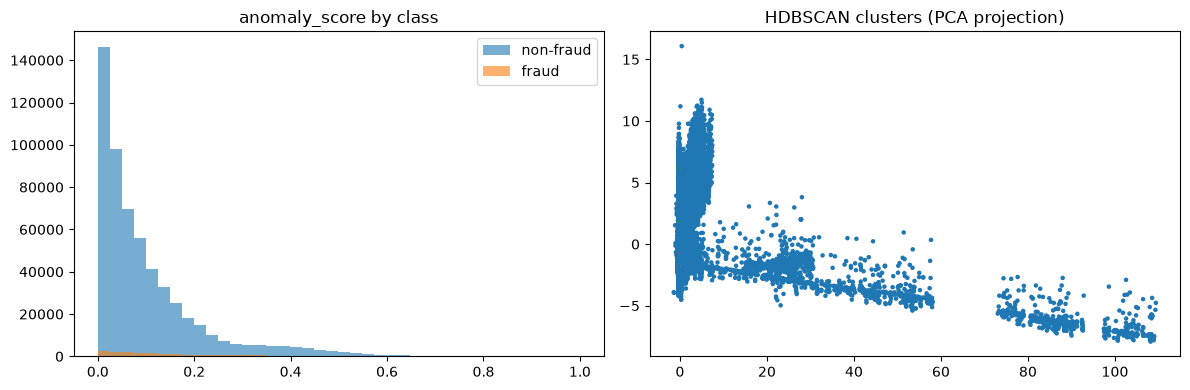

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df.loc[df[TARGET_COL]==0, "anomaly_score"], bins=40, alpha=0.6, label="non-fraud")
axes[0].hist(df.loc[df[TARGET_COL]==1, "anomaly_score"], bins=40, alpha=0.6, label="fraud")
axes[0].set_title("anomaly_score by class")
axes[0].legend()

sc = axes[1].scatter(X_pca[:,0], X_pca[:,1], c=df["cluster_id"], cmap="tab10", s=5)
axes[1].set_title("HDBSCAN clusters (PCA projection)")
plt.tight_layout()
plt.show()

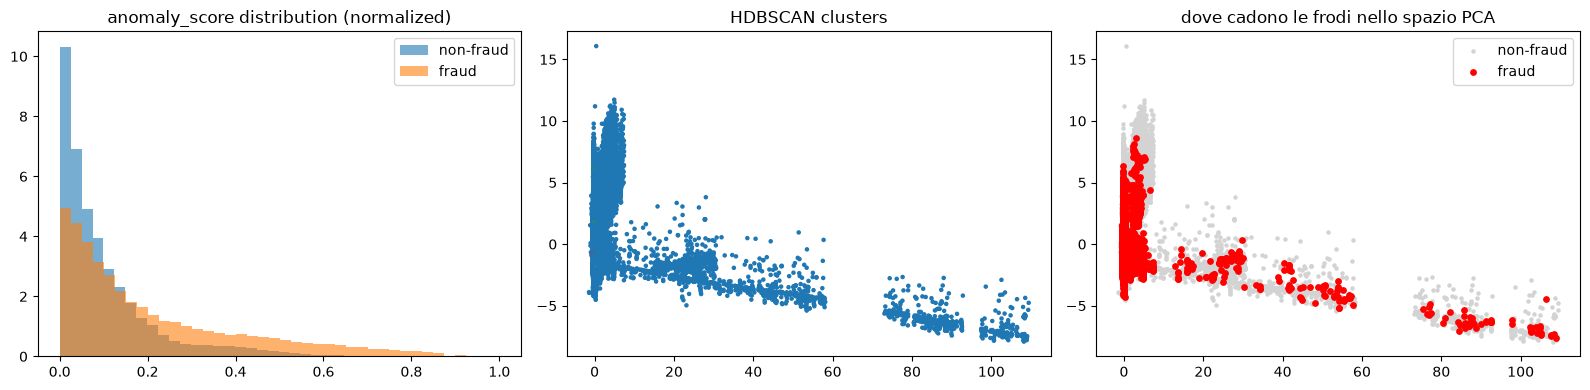

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df.loc[df[TARGET_COL]==0, "anomaly_score"], bins=40, density=True, alpha=0.6, label="non-fraud")
axes[0].hist(df.loc[df[TARGET_COL]==1, "anomaly_score"], bins=40, density=True, alpha=0.6, label="fraud")
axes[0].set_title("anomaly_score distribution (normalized)")
axes[0].legend()

axes[1].scatter(X_pca[:,0], X_pca[:,1], c=df["cluster_id"], cmap="tab10", s=5)
axes[1].set_title("HDBSCAN clusters")

mask_fraud = (df[TARGET_COL] == 1).values
axes[2].scatter(X_pca[~mask_fraud,0], X_pca[~mask_fraud,1], c="lightgray", s=5, label="non-fraud")
axes[2].scatter(X_pca[mask_fraud,0], X_pca[mask_fraud,1], c="red", s=15, label="fraud", zorder=5)
axes[2].set_title("dove cadono le frodi nello spazio PCA")
axes[2].legend()

plt.tight_layout()
plt.show()